# HPO for Dual-View SARF (Surface + Lemma, XLM-R Large) with Optuna Checkpointing

Hyper-parameter search for the `kusa_dual_view` architecture (shared XLM-R
encoder over surface + lemma, cross-attention, CNN + BiLSTM fusion head). Mirrors
`hpo_kusa_baseline` one-to-one in protocol so the searches are comparable.

Dual-View specifics:
- The encoder and the from-scratch head are optimised with **separate learning rates**, so `encoder_lr` and `head_lr` are tuned as two independent hyper-parameters instead of a single `lr`. `encoder_lr` shares the baseline's search space (it is the comparable, shared component); `head_lr` covers the higher range a randomly-initialised CNN/BiLSTM/attention head needs.
- The head **dropout** is also tuned, since it is an architecture-specific knob the baseline does not have.
- The dual-view needs a `lemma` column, so rows are filtered on both `surface` and `lemma` (see the data cell's note on split equivalence).


In [ ]:
!pip install optuna transformers datasets scikit-learn pandas matplotlib torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 28.3 MB/s eta 0:00:00


In [ ]:
import optuna
import os
import json
import urllib.request
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np
import random
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Retrieve notebook name automatically
try:
    req = urllib.request.urlopen('http://172.28.0.12:9000/api/sessions')
    sessions = json.loads(req.read())
    file_name = sessions[0]['name']
    NOTEBOOK_NAME = os.path.splitext(file_name)[0]
except:
    NOTEBOOK_NAME = "hpo_kusa_dual_view_fair"

print(f"Active Notebook Name: {NOTEBOOK_NAME}")

DIR_PATH = "/content/drive/MyDrive/google_colab/kusa"
DATA_PATH = DIR_PATH + "/datasets"
SAVE_DIR = DIR_PATH + "/" + NOTEBOOK_NAME

PREPROCESSED_KURDISENT_PATH = DATA_PATH + "/KurdiSent_preprocessed.csv"
os.makedirs(SAVE_DIR, exist_ok=True)

BERT_MODEL_NAME = "xlm-roberta-large"   # same

# HPO settings
N_TRIALS = 20
EPOCHS = 8
PATIENCE = 3
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


Mounted at /content/drive
Active Notebook Name: hpo_kusa_dual_view_fair


In [ ]:
# Load data
df = pd.read_csv(PREPROCESSED_KURDISENT_PATH, encoding='utf-8')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df = df.dropna(subset=['surface', 'lemma']).reset_index(drop=True)

# HPO trains on 80%, scores trials on 20%.
# No test set is locked away, the final evaluation is done via cross-validation
# in the standalone notebook.
hpo_train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)

hpo_train_df = hpo_train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Full: {len(df)} | HPO-train (80%): {len(hpo_train_df)} | Val (20%): {len(val_df)}")

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)


class DualViewSurfaceLemmaDataset(Dataset):

    def __init__(self, df, tokenizer, max_len=128):
        self.surface   = df["surface"].tolist()
        self.lemma     = df["lemma"].tolist()
        self.labels    = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def encode(self, text):
        enc = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0)
        }

    def __getitem__(self, idx):
        return {
            "surface": self.encode(self.surface[idx]),
            "lemma":   self.encode(self.lemma[idx]),
            "labels":  torch.tensor(self.labels[idx], dtype=torch.long),
        }


def dual_surface_lemma_collator(features):
    batch = {}
    for key in ["surface", "lemma"]:
        batch[key] = {
            "input_ids":      torch.stack([f[key]["input_ids"]      for f in features]),
            "attention_mask": torch.stack([f[key]["attention_mask"] for f in features])
        }
    batch["labels"] = torch.stack([f["labels"] for f in features])
    return batch


Full: 12306 | HPO-train (80%): 9844 | Val (20%): 2462


config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [ ]:
class DualViewCNNBiLSTMAttention(nn.Module):
    def __init__(
        self,
        bert_model_name="xlm-roberta-large",
        lstm_hidden_dim=128,
        cnn_filters=200,
        kernel_sizes=(3, 4, 5),
        num_classes=3,
        dropout=0.3
    ):
        super(DualViewCNNBiLSTMAttention, self).__init__()

        base_model = AutoModelForSequenceClassification.from_pretrained(
            bert_model_name, return_dict=True, num_labels=num_classes
        )
        self.encoder = base_model.roberta if hasattr(base_model, "roberta") else base_model.bert
        bert_hidden_dim = self.encoder.config.hidden_size

        self.cross_attn_lemma = nn.MultiheadAttention(
            embed_dim=bert_hidden_dim, num_heads=8, batch_first=True
        )

        self.convs = nn.ModuleList([
            nn.Conv2d(
                in_channels=1,
                out_channels=cnn_filters,
                kernel_size=(k, bert_hidden_dim)
            )
            for k in kernel_sizes
        ])

        self.bilstm = nn.LSTM(
            input_size=bert_hidden_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )

        fused_dim = (cnn_filters * len(kernel_sizes)) + (lstm_hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(fused_dim, num_classes)

    def forward(self, surface, lemma):
        surface_mask = surface["attention_mask"]
        lemma_mask   = lemma["attention_mask"]

        surface_out = self.dropout(self.encoder(**surface).last_hidden_state)
        lemma_out   = self.dropout(self.encoder(**lemma).last_hidden_state)

        lemma_key_padding_mask = (lemma_mask == 0)
        lemma_attn, _ = self.cross_attn_lemma(
            query=surface_out, key=lemma_out, value=lemma_out,
            key_padding_mask=lemma_key_padding_mask
        )

        cross_attended = (surface_out + lemma_attn) / 2.0

        pad_mask_2d = (surface_mask == 0).unsqueeze(-1)
        cross_attended = cross_attended.masked_fill(pad_mask_2d, 0.0)
        cross_attended = self.dropout(cross_attended)

        pad_mask_4d = (surface_mask == 0).unsqueeze(1).unsqueeze(-1)
        cnn_input   = surface_out.unsqueeze(1).masked_fill(pad_mask_4d, 0.0)

        cnn_features = []
        for conv in self.convs:
            x = F.relu(conv(cnn_input)).squeeze(3)
            x = F.max_pool1d(x, kernel_size=x.size(2)).squeeze(2)
            cnn_features.append(x)
        cnn_out = torch.cat(cnn_features, dim=1)

        lengths      = surface_mask.sum(dim=1).cpu()
        packed_input = nn.utils.rnn.pack_padded_sequence(
            cross_attended, lengths, batch_first=True, enforce_sorted=False
        )
        packed_output, _ = self.bilstm(packed_input)
        lstm_out, _      = nn.utils.rnn.pad_packed_sequence(
            packed_output, batch_first=True, total_length=surface_mask.size(1)
        )

        input_mask_expanded = surface_mask.unsqueeze(-1).expand(lstm_out.size()).float()
        sum_embeddings = torch.sum(lstm_out * input_mask_expanded, dim=1)
        sum_mask       = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        lstm_pooled    = sum_embeddings / sum_mask

        fused  = torch.cat((cnn_out, lstm_pooled), dim=1)
        output = self.dropout(fused)
        logits = self.fc(output)
        return logits


In [ ]:
def run_trial(train_loader, eval_loader, encoder_lr, head_lr, weight_decay,
              warmup_ratio, dropout, seed=SEED, trial=None):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # distinct, reproducible per-trial seed instead of the same global SEED.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Dual-View model: shared XLM-R encoder + CNN/BiLSTM/cross-attention head.
    model = DualViewCNNBiLSTMAttention(
        bert_model_name=BERT_MODEL_NAME, num_classes=3, dropout=dropout
    )
    model.to(device)

    # Separate learning rates: pretrained encoder vs. from-scratch head.
    encoder_params = list(model.encoder.parameters())
    head_params    = [p for n, p in model.named_parameters() if "encoder" not in n]
    optimizer = optim.AdamW([
        {"params": encoder_params, "lr": encoder_lr},
        {"params": head_params,    "lr": head_lr},
    ], weight_decay=weight_decay)

    total_steps = len(train_loader) * EPOCHS
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )

    criterion = nn.CrossEntropyLoss()

    best_eval_f1 = 0.0
    best_model_state = None      # keep best weights in memory
    patience_counter = 0

    try:
        for epoch in range(EPOCHS):
            model.train()
            for batch in tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{EPOCHS}", leave=False):
                surface = {k: v.to(device) for k, v in batch["surface"].items()}
                lemma   = {k: v.to(device) for k, v in batch["lemma"].items()}
                labels  = batch["labels"].to(device)

                optimizer.zero_grad()
                outputs = model(surface, lemma)
                loss = criterion(outputs, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()

            model.eval()
            eval_preds, eval_labels_list = [], []
            with torch.no_grad():
                for batch in eval_loader:
                    surface = {k: v.to(device) for k, v in batch["surface"].items()}
                    lemma   = {k: v.to(device) for k, v in batch["lemma"].items()}
                    labels  = batch["labels"].to(device)

                    outputs = model(surface, lemma)
                    preds = torch.argmax(outputs, dim=1)
                    eval_preds.extend(preds.cpu().numpy())
                    eval_labels_list.extend(labels.cpu().numpy())

            eval_f1 = f1_score(eval_labels_list, eval_preds, average='macro')
            print(f"Epoch {epoch+1} | Eval F1 (Macro): {eval_f1:.4f}")

            # checkpoint best weights
            if eval_f1 > best_eval_f1:
                best_eval_f1 = eval_f1
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            # report to Optuna and prune unpromising trials
            if trial is not None:
                trial.report(eval_f1, step=epoch)
                if trial.should_prune():
                    del model, optimizer, scheduler
                    torch.cuda.empty_cache()
                    raise optuna.TrialPruned()

            # early stopping on the validation
            if patience_counter >= PATIENCE:
                print("Early stopping triggered.")
                break

        # restore best weights before returning
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
    finally:
        # ensure cleanup even if pruned/raised
        try:
            del model, optimizer, scheduler
        except NameError:
            pass
        torch.cuda.empty_cache()

    return best_eval_f1


In [ ]:
def objective(trial):
    batch_size   = trial.suggest_categorical("batch_size", [16, 32])
    encoder_lr   = trial.suggest_categorical("encoder_lr", [5e-6, 1e-5, 2e-5, 3e-5])
    head_lr      = trial.suggest_categorical("head_lr", [5e-4, 1e-3, 2e-3])
    weight_decay = trial.suggest_categorical("weight_decay", [0.0, 0.01, 0.1])
    warmup_ratio = trial.suggest_categorical("warmup_ratio", [0.05, 0.1, 0.2])
    dropout      = trial.suggest_categorical("dropout", [0.1, 0.3, 0.5])

    print(f"\nStarting Trial {trial.number}: batch_size={batch_size}, "
          f"encoder_lr={encoder_lr}, head_lr={head_lr}, weight_decay={weight_decay}, "
          f"warmup_ratio={warmup_ratio}, dropout={dropout}")

    train_dataset = DualViewSurfaceLemmaDataset(hpo_train_df, tokenizer)
    val_dataset   = DualViewSurfaceLemmaDataset(val_df, tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              collate_fn=dual_surface_lemma_collator)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                              collate_fn=dual_surface_lemma_collator)

    # distinct seed per trial (reproducible)
    trial_seed = SEED + trial.number

    return run_trial(train_loader, val_loader, encoder_lr, head_lr, weight_decay,
                     warmup_ratio, dropout, seed=trial_seed, trial=trial)


In [ ]:
# SQLite database on Google Drive to survive Colab timeouts
storage_path = f"sqlite:///{SAVE_DIR}/hpo_kusa_dual_view_fair_study.db"

study = optuna.create_study(
    study_name="hpo_kusa_dual_view_fair",
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3),  # Fix 9
    storage=storage_path,
    load_if_exists=True,
)

# 20 FINISHED trials will stop this
FINISHED_STATES = (
    optuna.trial.TrialState.COMPLETE,
    optuna.trial.TrialState.PRUNED,
    optuna.trial.TrialState.FAIL,
)
counted = len([t for t in study.trials if t.state in FINISHED_STATES])
remaining = max(0, N_TRIALS - counted)
print(f"Counted trials (incl. pruned): {counted} | Remaining: {remaining}")

if remaining > 0:
    study.optimize(objective, n_trials=remaining)
else:
    print("All trials already completed.")

print("\n========== HPO Results ==========")
print(f"Best Validation Macro-F1: {study.best_value:.4f}")
print("Best parameters:")
for k, v in study.best_params.items():
    print(f"  {k:20s}: {v}")

[I 2026-06-30 19:06:34,691] Using an existing study with name 'hpo_kusa_dual_view_fair' instead of creating a new one.


Counted trials (incl. pruned): 18 | Remaining: 2

Starting Trial 20: batch_size=16, encoder_lr=1e-05, head_lr=0.001, weight_decay=0.0, warmup_ratio=0.2, dropout=0.1


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Epoch 3 | Eval F1 (Macro): 0.8173


Training Epoch 4/8:   0%|          | 0/616 [00:00<?, ?it/s]

Epoch 4 | Eval F1 (Macro): 0.8311


[I 2026-06-30 20:42:36,654] Trial 21 pruned. 



========== HPO Results ==========
Best Validation Macro-F1: 0.8572
Best parameters:
  batch_size          : 16
  encoder_lr          : 5e-06
  head_lr             : 0.001
  weight_decay        : 0.0
  warmup_ratio        : 0.2
  dropout             : 0.3


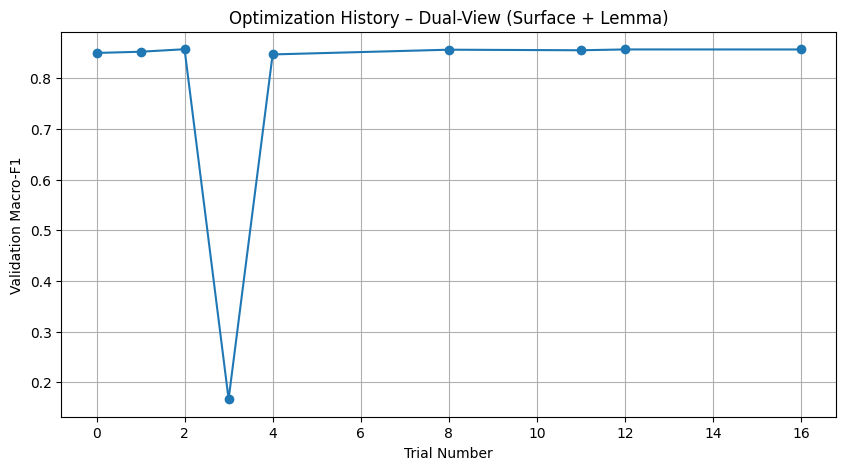

In [ ]:
# Visualize
try:
    trials_df = study.trials_dataframe()
    trials_df = trials_df[trials_df["state"] == "COMPLETE"].reset_index(drop=True)

    if len(trials_df) > 0:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(trials_df["number"], trials_df["value"], marker='o')
        ax.set_xlabel("Trial Number")
        ax.set_ylabel("Validation Macro-F1")
        ax.set_title("Optimization History – Dual-View (Surface + Lemma)")
        ax.grid()
        plt.savefig(os.path.join(SAVE_DIR, "optimization_history.png"))
        plt.show()
except Exception as e:
    print(f"Visualization failed: {e}")
